In [1]:
%load_ext autoreload
%autoreload 2

# SRE-DQN vs Nash-DQN Visualization

Load the Nash-DQN and LLQ SRE-DQN checkpoints for the configured seed and generate the previous comparison plots/evaluation artifacts.

In [2]:
from pathlib import Path
import os
import pickle
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / 'AGENTS.md').exists() and (path / 'continuous_action_space').exists():
            return path
    raise RuntimeError('Could not locate repo root')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXPERIMENT_DIR = REPO_ROOT / 'continuous_action_space' / 'trading_competition'
MODEL_ROOT = EXPERIMENT_DIR / 'pt_files'
EVAL_ROOT = EXPERIMENT_DIR / 'evaluation'
EVAL_ROOT.mkdir(parents=True, exist_ok=True)

from continuous_action_space.locally_linear_quadratic.NashAgent_lib import NashNN
from continuous_action_space.locally_linear_quadratic.sre_agent import SreNN
from continuous_action_space.trading_competition.visualization import (
    collect_mixed_rewards,
    draw_heatmap,
    find_latest_model_dir,
    load_best_checkpoint_into_agent,
    loss_history_from_checkpoint,
    make_policy_spec,
    to_State_mesh,
    to_State_mesh_sre,
)

np.set_printoptions(precision=4)


def build_nash_agent_from_config():
    return NashNN(**NET_KWARGS)


def build_sre_agent_from_config():
    return SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )


print('Repo root:', REPO_ROOT)
print('Model root:', MODEL_ROOT)
print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')

Repo root: /home/wowthecoder/SRE-DQN
Model root: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files
Using device: cuda


## Shared Market Environment

Identical parameters to `NashDQN-Training.ipynb`. Both agents are trained on this same environment.

In [3]:
from continuous_action_space.trading_competition.experiment_config import (
    NUM_PLAYERS as num_players,
    sim_dict,
    norm_mean,
    norm_std,
    T,
    make_sim_obj,
    NET_KWARGS,
    SRE_EPS_REG,
    SRE_DELTA_MIN,
    SRE_GAMMA,
)

sim_obj = make_sim_obj()

print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item())

Agents: 5 | T= 5 | dt= 0.5


## Visualization Configuration


In [4]:
from continuous_action_space.trading_competition.experiment_config import (
    seed_everything,
    eps_slug,
    seed_slug,
    BASE_SEED,
    MAX_STEPS,
    LLQ_SRE_EPS_LIST,
    SRE_EPS_REG,
)

# Keep the previous notebook's variable names while loading the current LLQ SRE runs.
SRE_EPS_LIST = LLQ_SRE_EPS_LIST
EVAL_SEED = BASE_SEED + 1

RUN_TAG = seed_slug(BASE_SEED)

NASH_MODEL_DIR = find_latest_model_dir('nash', root_dir=str(MODEL_ROOT), seed=BASE_SEED)
SRE_MODEL_DIRS = {
    eps: find_latest_model_dir(f'llq_sre_eps_{eps_slug(eps)}', root_dir=str(MODEL_ROOT), seed=BASE_SEED)
    for eps in SRE_EPS_LIST
}
EVAL_DIR = EVAL_ROOT / RUN_TAG
EVAL_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(BASE_SEED)

print('Loaded Nash model dir:', NASH_MODEL_DIR)
print('Loaded SRE model dirs:')
for eps in SRE_EPS_LIST:
    print(f'  eps={eps:g}:', SRE_MODEL_DIRS[eps])
print('Evaluation dir:', EVAL_DIR)
print('Seeds | base:', BASE_SEED, '| eval:', EVAL_SEED)

Loaded Nash model dir: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/nash_seed_20260409
Loaded SRE model dirs:
  eps=0: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0_seed_20260409
  eps=0.01: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p01_seed_20260409
  eps=0.1: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p1_seed_20260409
  eps=0.5: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p5_seed_20260409
  eps=1: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_1_seed_20260409
Evaluation dir: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/evaluation/seed_20260409
Seeds | base: 20260409 | eval: 20260410


## Load Best Checkpoints

Run this cell after the training notebook has saved checkpoints to restore the configured-seed best Nash/SRE models before plotting heatmaps and evaluations.

In [5]:
nash_agent = build_nash_agent_from_config()
nash_best_checkpoint_path, nash_best_checkpoint = load_best_checkpoint_into_agent(nash_agent, NASH_MODEL_DIR)
nash_loss = loss_history_from_checkpoint(nash_best_checkpoint)
print(
    f"Loaded Nash best checkpoint from iteration {nash_best_checkpoint['iteration']} "
    f"with loss {nash_best_checkpoint['best_loss']:.4f}"
)

sre_agents = {}
sre_losses = {}
sre_best_checkpoint_paths = {}
sre_best_checkpoints = {}
for eps in SRE_EPS_LIST:
    sre_agents[eps] = build_sre_agent_from_config()
    checkpoint_path, checkpoint = load_best_checkpoint_into_agent(sre_agents[eps], SRE_MODEL_DIRS[eps])
    sre_best_checkpoint_paths[eps] = checkpoint_path
    sre_best_checkpoints[eps] = checkpoint
    sre_losses[eps] = loss_history_from_checkpoint(checkpoint)
    print(
        f"Loaded SRE best checkpoint (eps={eps:g}) from iteration {checkpoint['iteration']} "
        f"with loss {checkpoint['best_loss']:.4f}"
    )

print('Loaded all requested SRE best checkpoints.')


CUDA IS AVAILABLE!
Loaded Nash best checkpoint from iteration 2036 with loss 919.6309
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0) from iteration 2036 with loss 891.9045
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.01) from iteration 2036 with loss 896.0034
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.1) from iteration 1753 with loss 925.0045
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.5) from iteration 2036 with loss 827.0374
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=1) from iteration 639 with loss 19830.7539
Loaded all requested SRE best checkpoints.


## Training Loss Curves

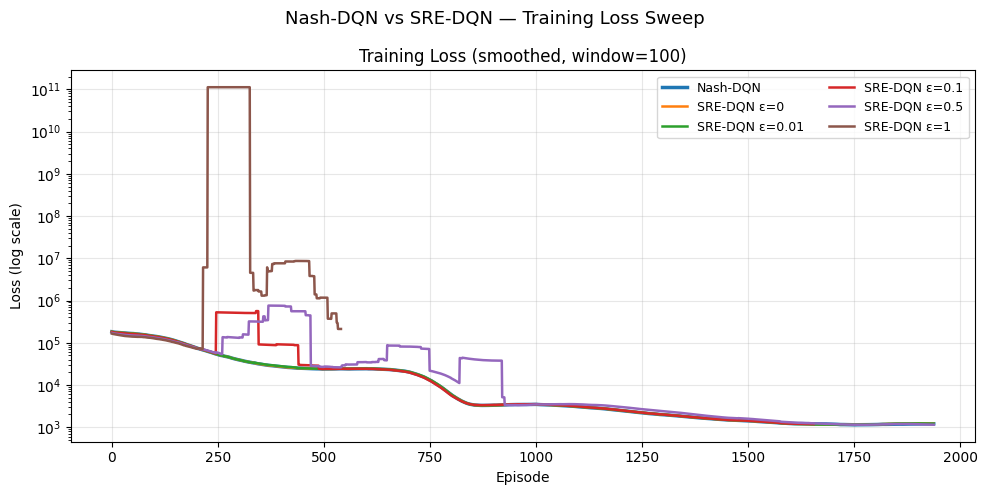

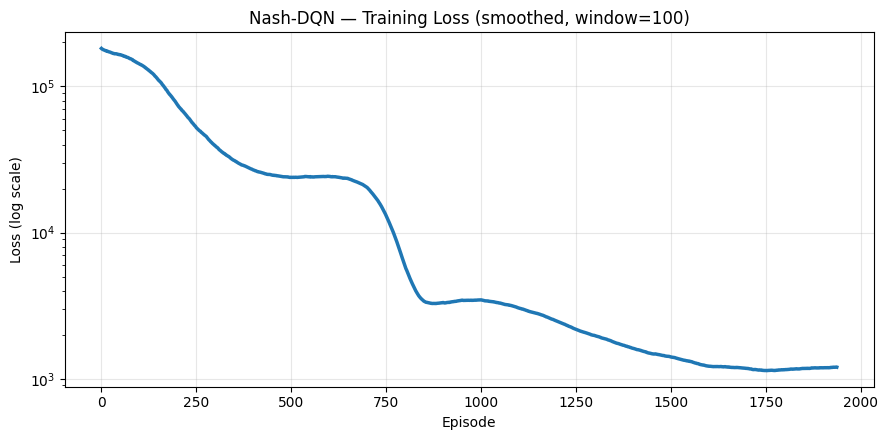

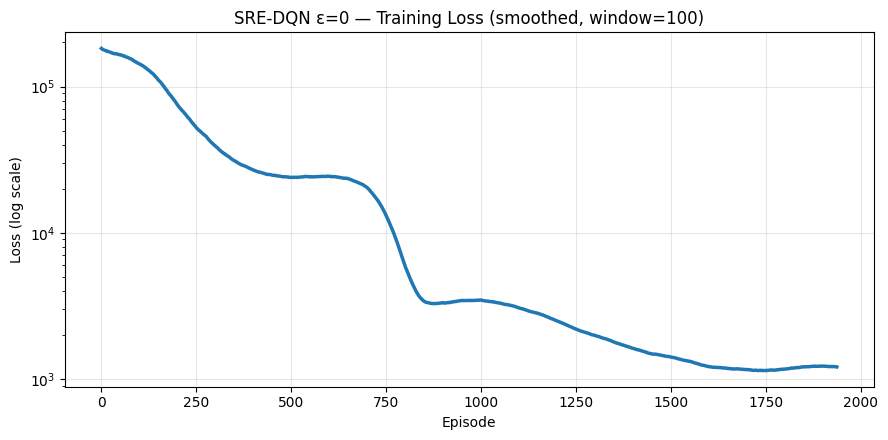

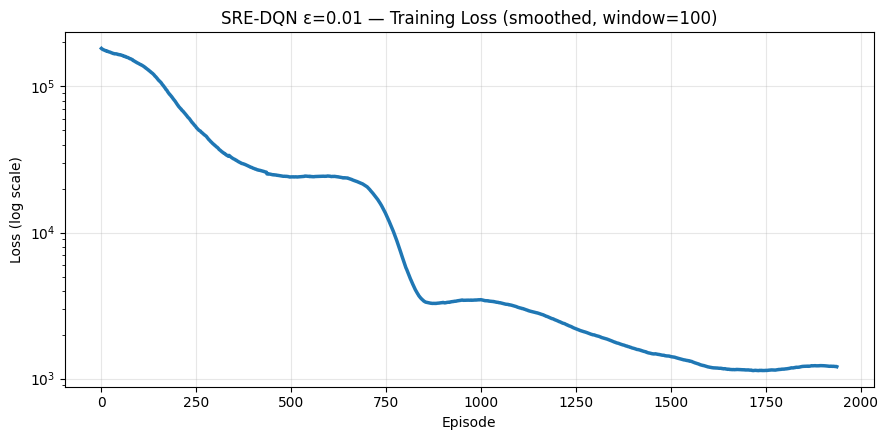

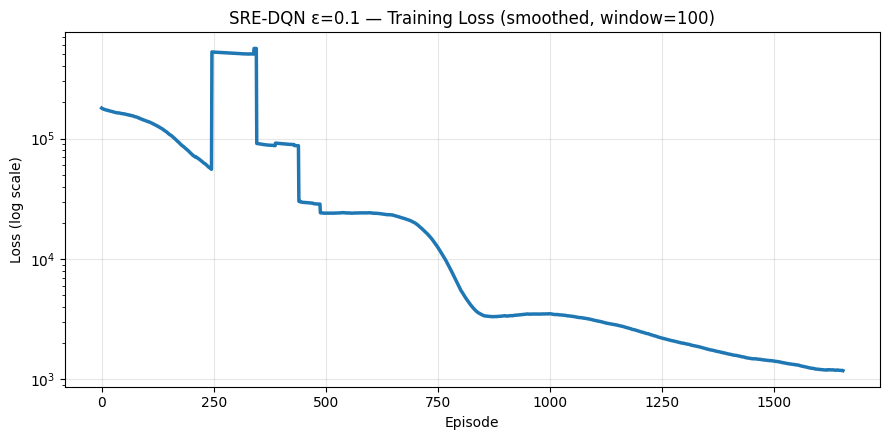

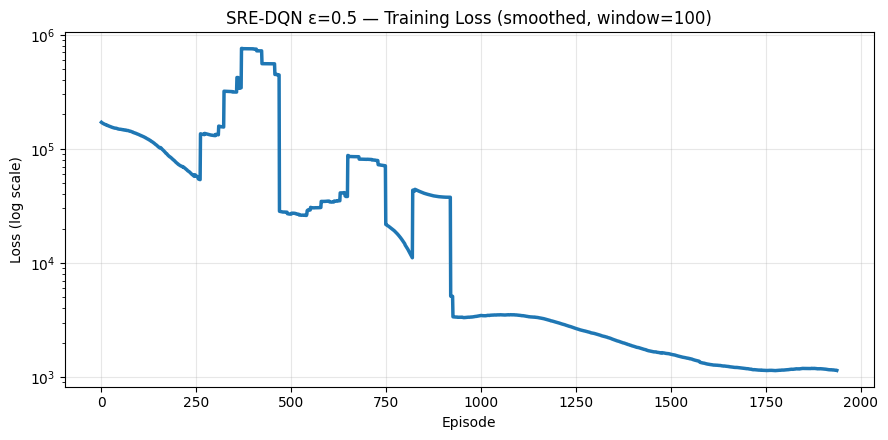

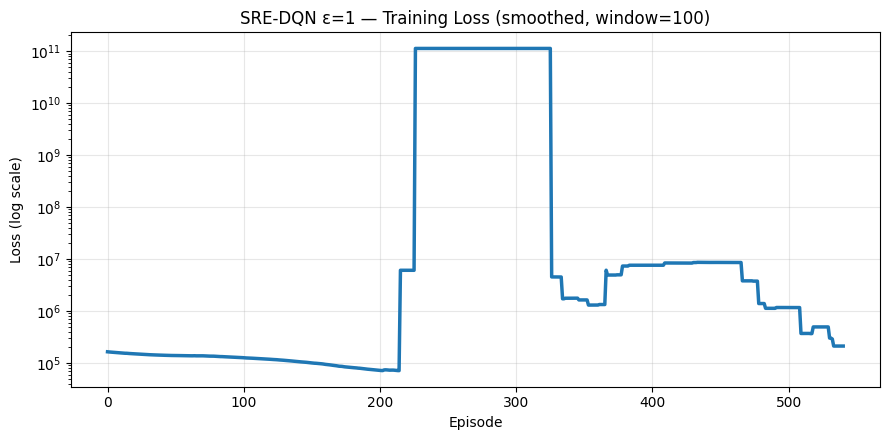

In [6]:

def smooth(arr, window=100):
    arr = np.asarray(arr)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


SMOOTH_WINDOW = 100

# Combined comparison figure
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(nash_loss, window=SMOOTH_WINDOW), linewidth=2.5, label='Nash-DQN')
for eps in SRE_EPS_LIST:
    ax.plot(smooth(sre_losses[eps], window=SMOOTH_WINDOW), linewidth=1.8, label=f'SRE-DQN ε={eps:g}')
ax.set_yscale('log')
ax.set_xlabel('Episode')
ax.set_ylabel('Loss (log scale)')
ax.set_title(f'Training Loss (smoothed, window={SMOOTH_WINDOW})')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle('Nash-DQN vs SRE-DQN — Training Loss Sweep', fontsize=13)
plt.tight_layout()
os.makedirs(EVAL_DIR, exist_ok=True)
fig.savefig(os.path.join(EVAL_DIR, 'training_loss_sweep_smoothed.png'), dpi=150, bbox_inches='tight')
plt.show()

# Individual model figures
individual_specs = [
    ('Nash-DQN', nash_loss, 'training_loss_nash_smoothed.png'),
] + [
    (f'SRE-DQN ε={eps:g}', sre_losses[eps], f'training_loss_sre_eps_{eps_slug(eps)}_smoothed.png')
    for eps in SRE_EPS_LIST
]

for label, loss_arr, file_name in individual_specs:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(smooth(loss_arr, window=SMOOTH_WINDOW), linewidth=2.5)
    ax.set_yscale('log')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(f'{label} — Training Loss (smoothed, window={SMOOTH_WINDOW})')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(EVAL_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


## Policy Heatmaps — Nash-DQN

Each panel shows the optimal action (trade rate) as a function of (time remaining, inventory) at a fixed price level.

=== Nash-DQN Policy Heatmaps ===
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


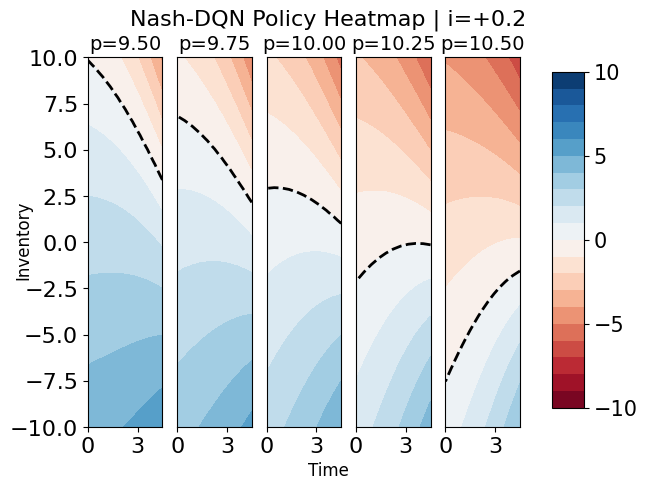

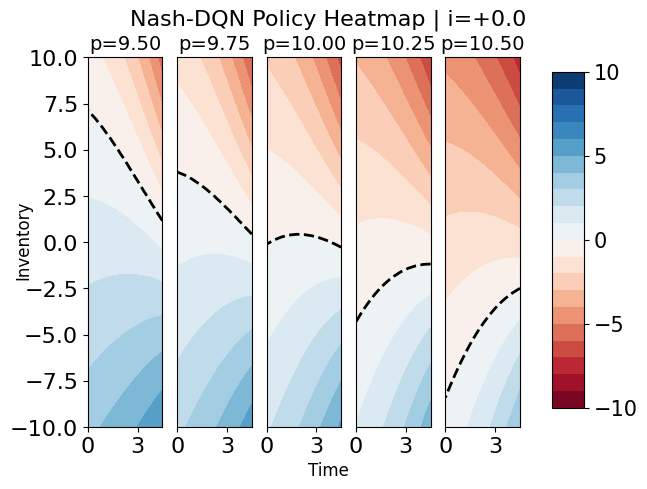

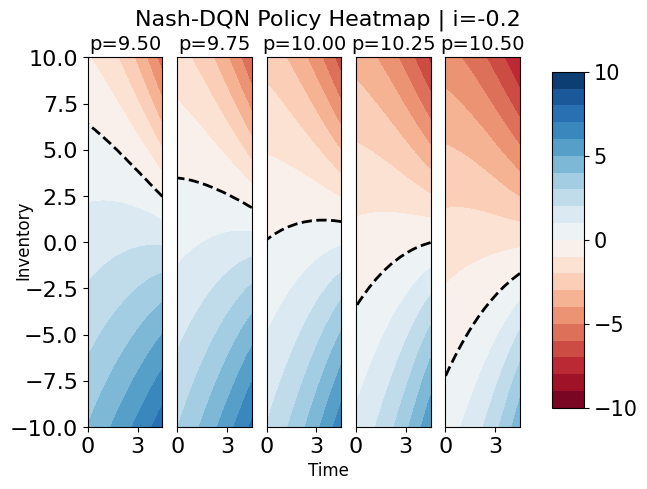

In [7]:

heatmap_kwargs = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5],
    q_range=[-10, 10],
    p_range=[9.5, 10.5],
    n_agents=num_players,
    other_agent_inv=0,
    a_range=[-10, 10],
    T=T,
    norm_mean=norm_mean,
    norm_std=norm_std,
    is_numpy=False,
    norm_input=True,
)

print('=== Nash-DQN Policy Heatmaps ===')
for i_val in [0.2, 0.0, -0.2]:
    draw_heatmap(
        net=nash_agent,
        i_val=i_val,
        file_path=os.path.join(NASH_MODEL_DIR, f'policy_heatmap_nash_i{i_val:+.1f}.png'),
        figure_title=f'Nash-DQN Policy Heatmap | i={i_val:+.1f}',
        **heatmap_kwargs,
    )



## Policy Heatmaps — SRE-DQN Sweep

For each trained SRE agent, this section plots the learned Nash action `μ` across the requested epsilon sweep.


=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


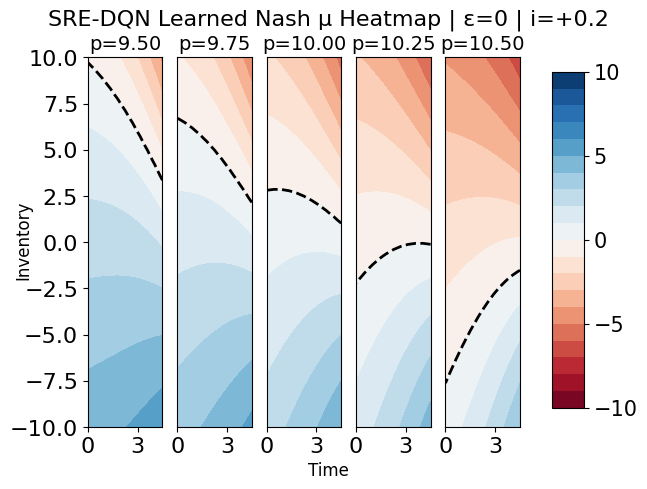

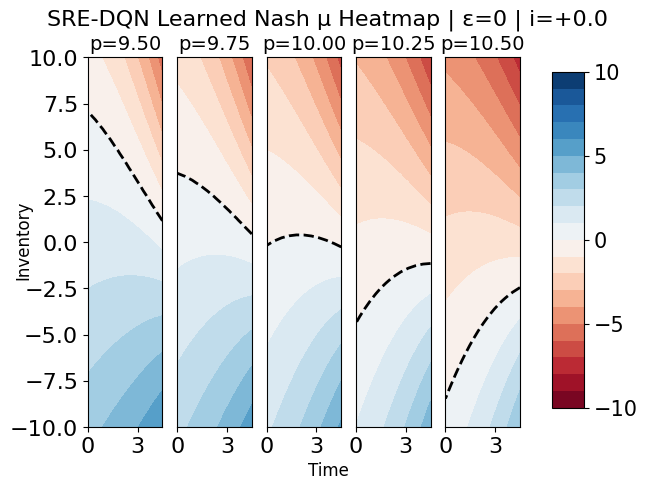

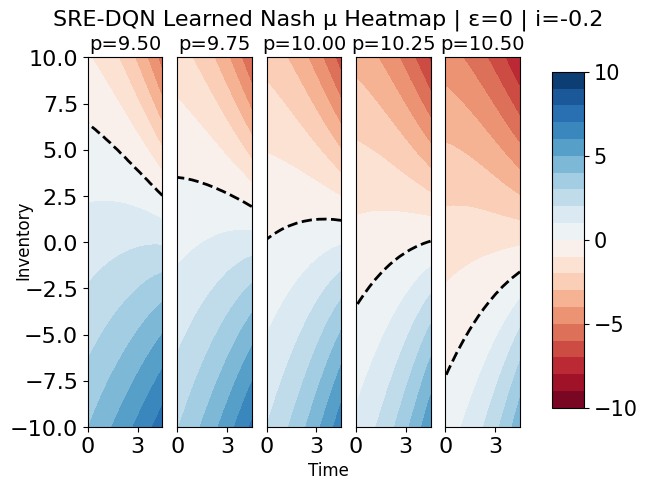

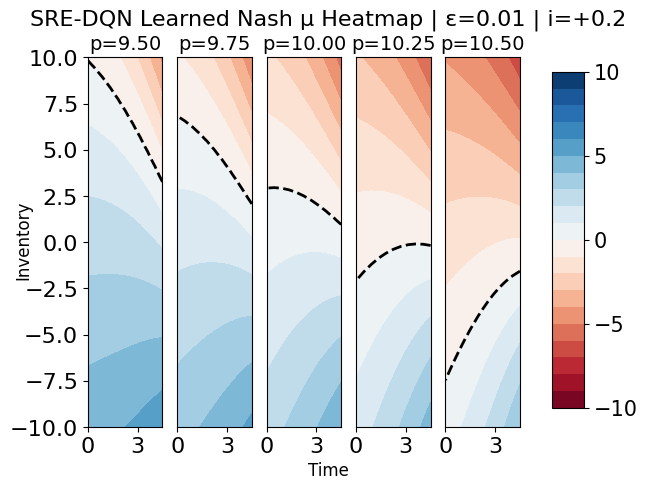

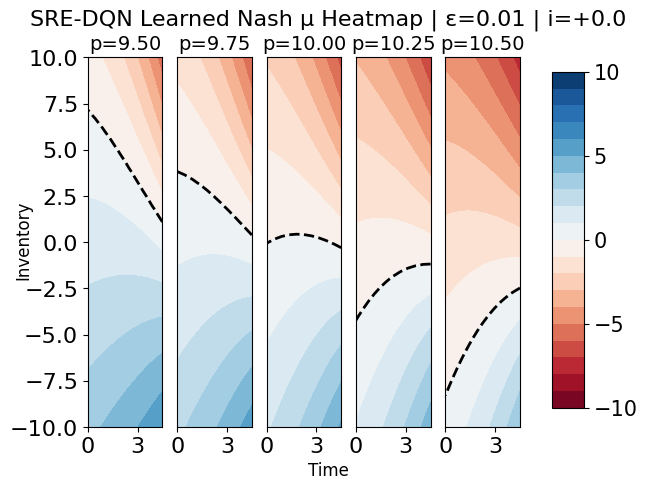

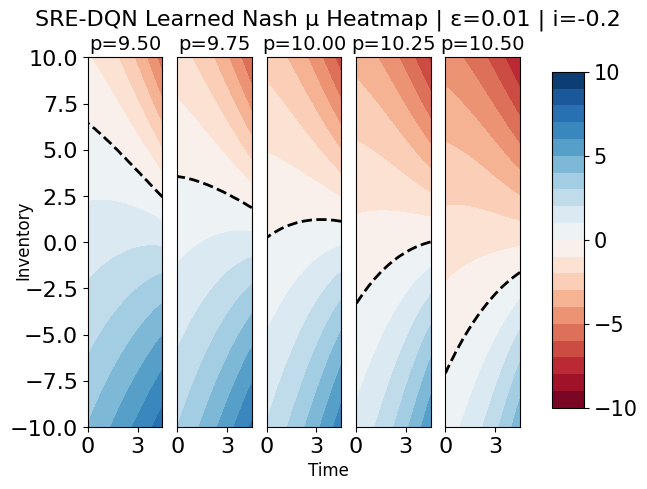

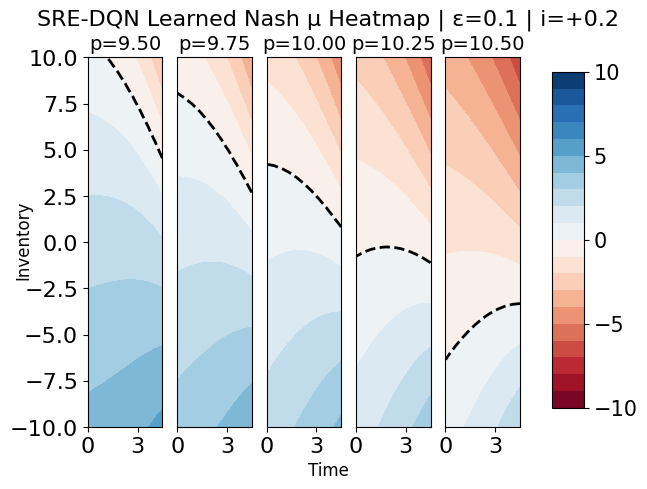

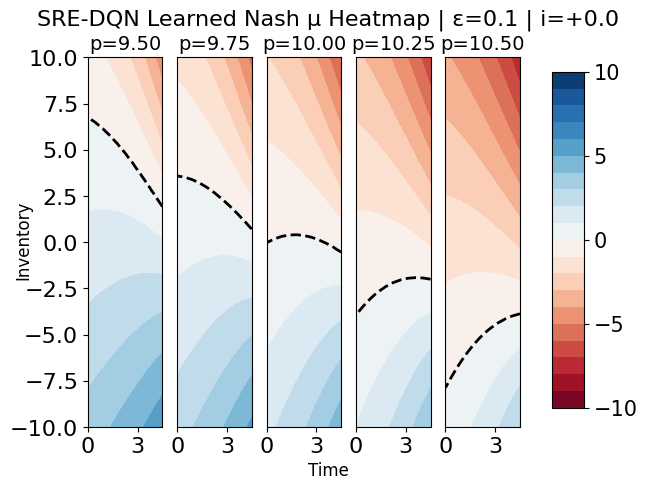

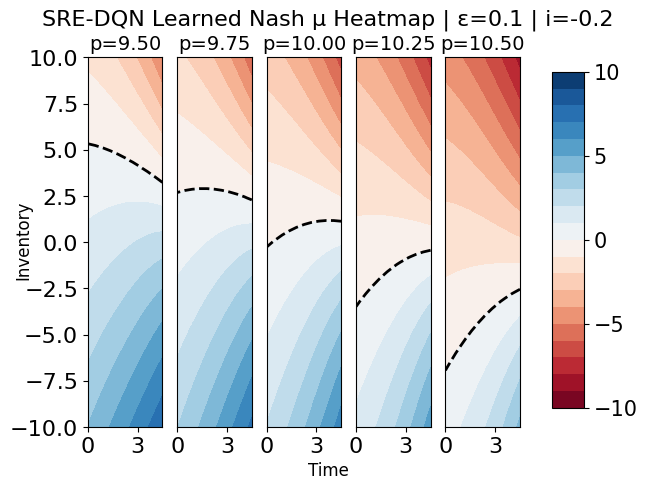

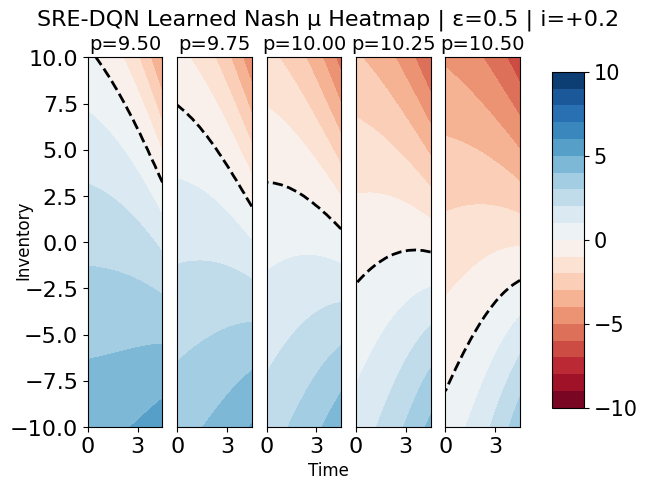

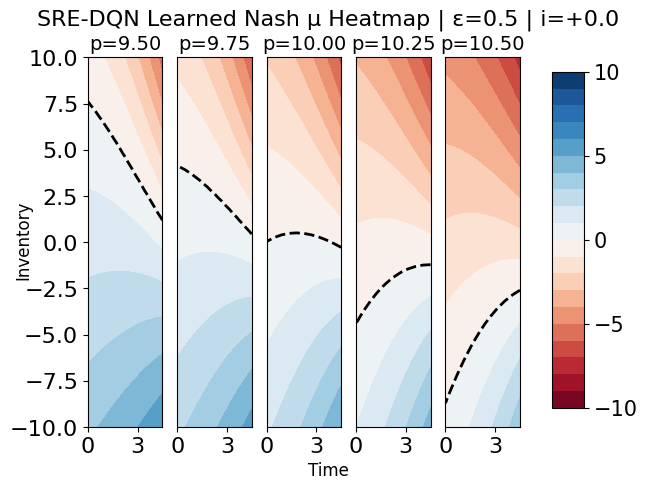

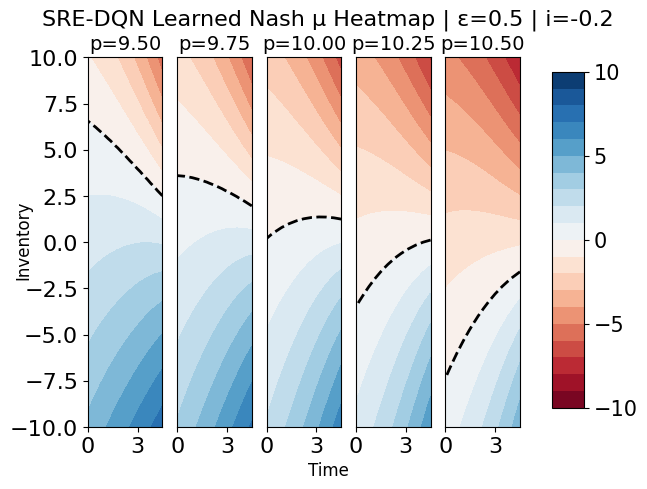

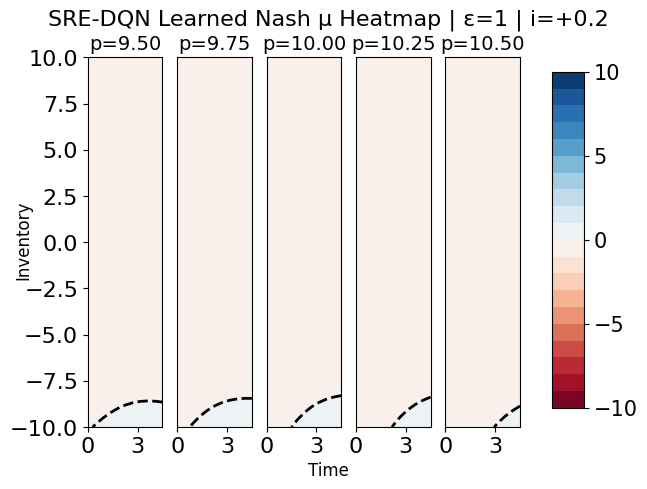

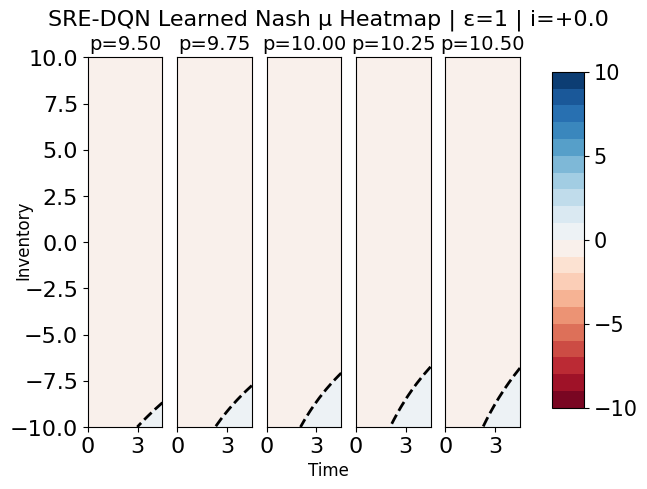

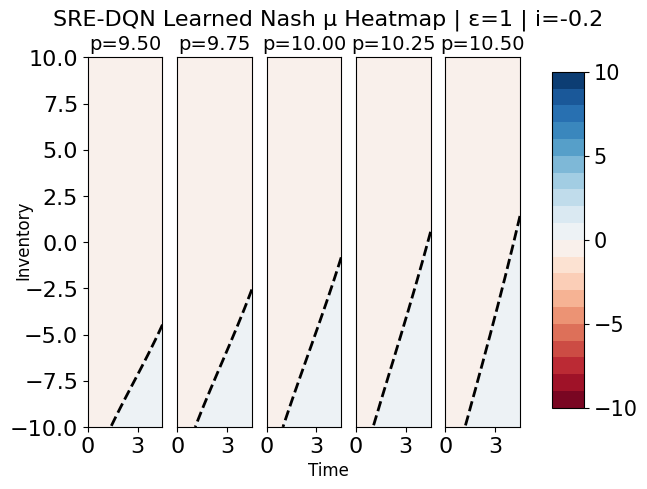

In [8]:

print('=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_mu_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            figure_title=f'SRE-DQN Learned Nash μ Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )



## Policy Heatmaps — SRE-Corrected Action Sweep

These heatmaps show the actual SRE action `μ^SR = μ + ε·correction` for each trained epsilon, with no epsilon decay.


=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/visualization.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


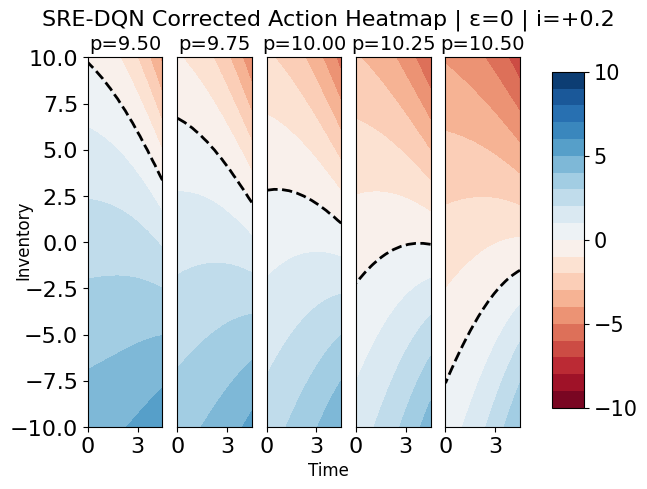

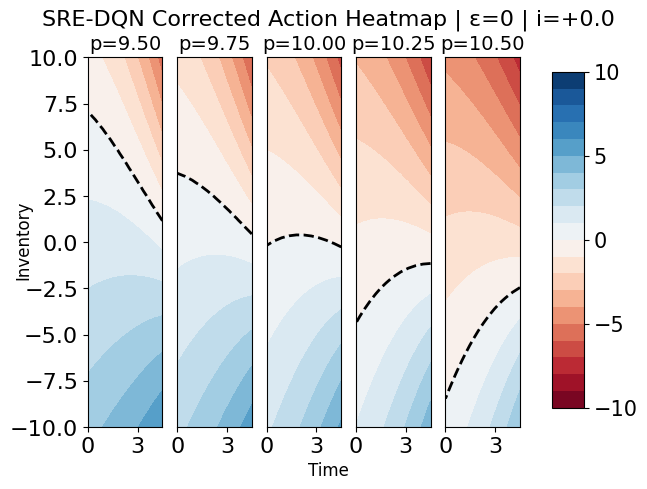

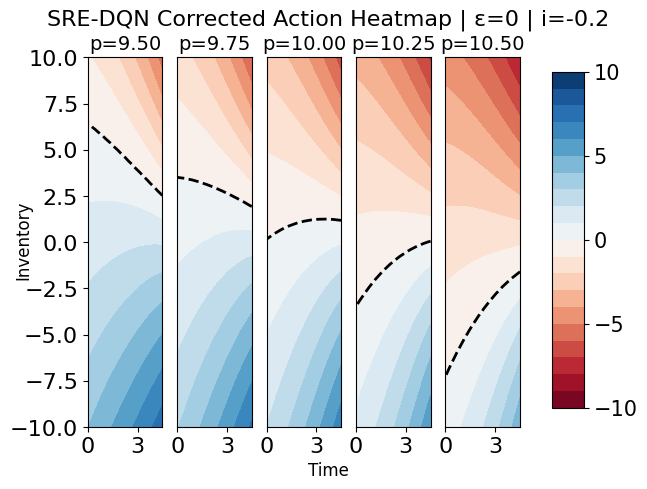

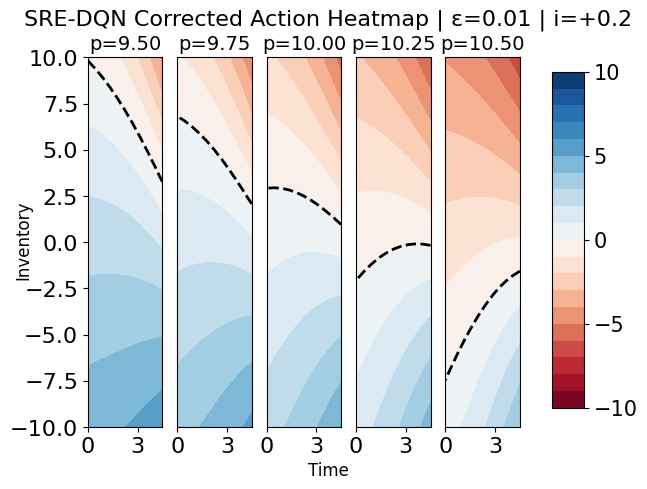

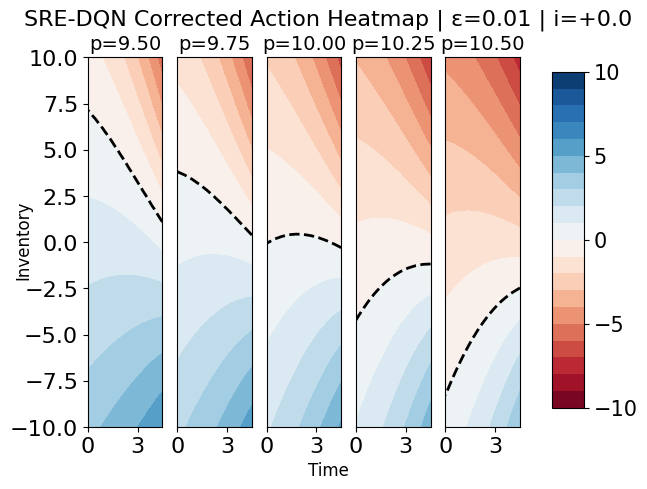

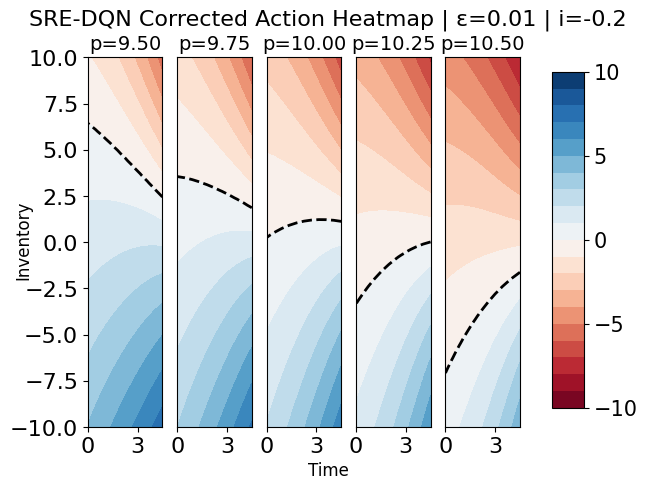

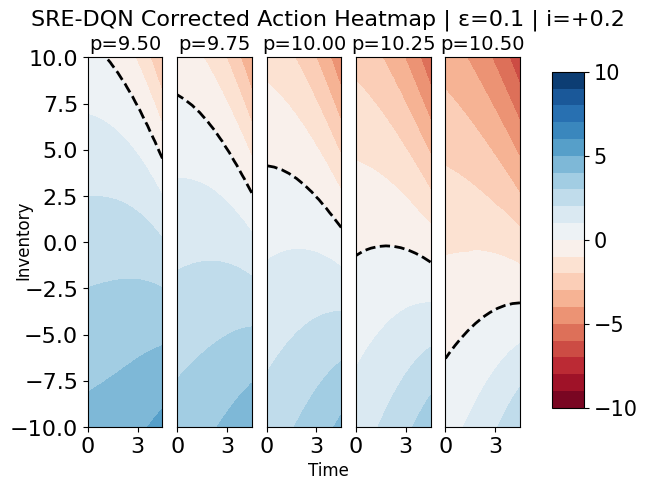

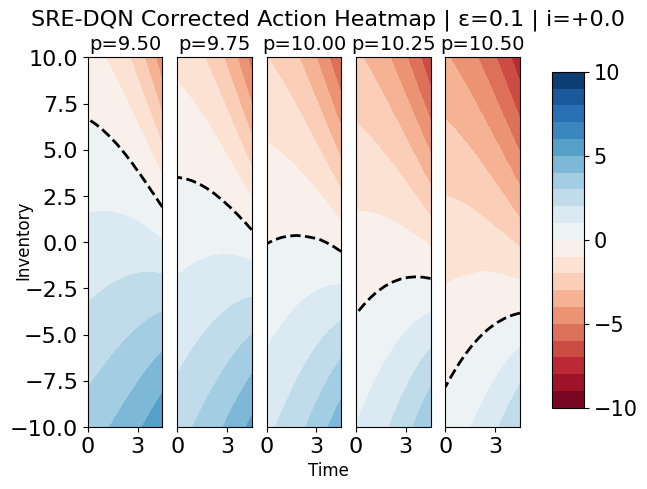

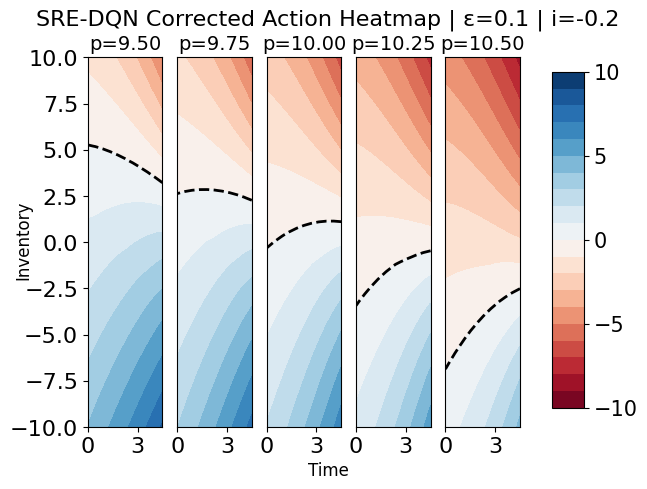

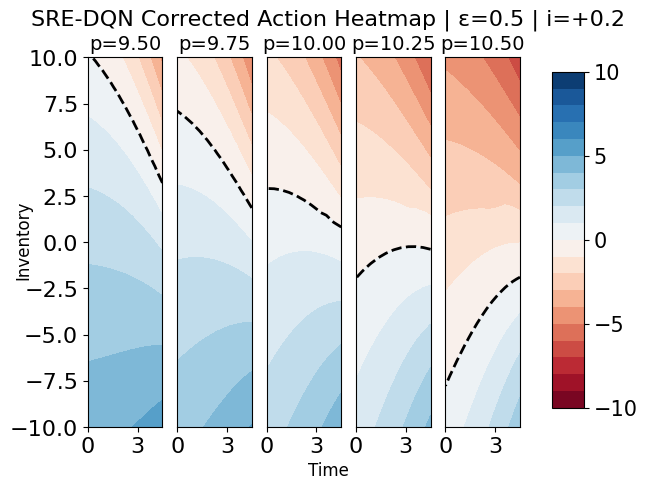

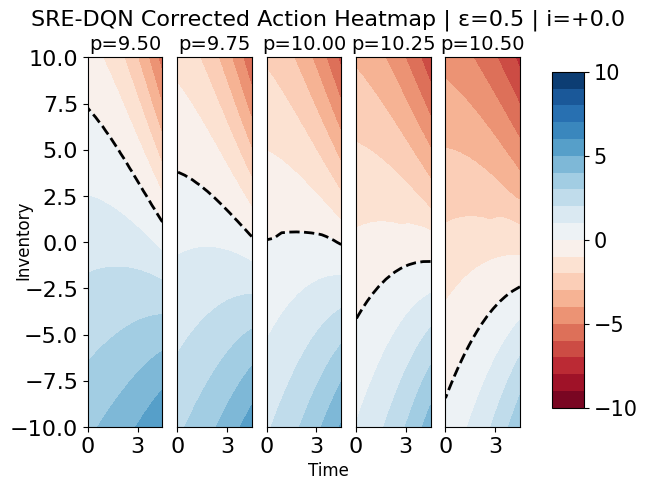

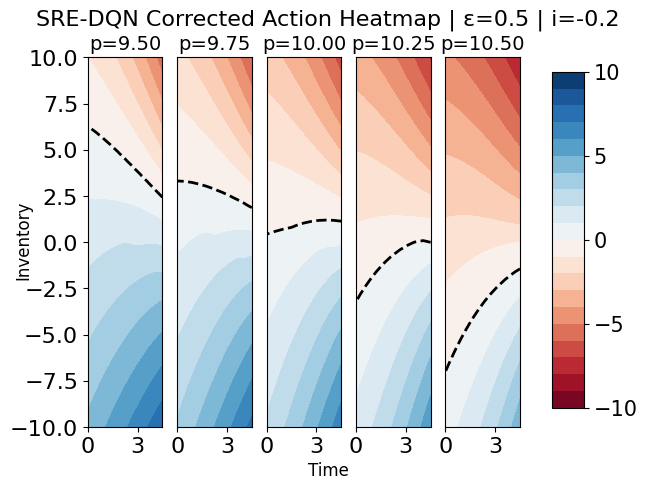

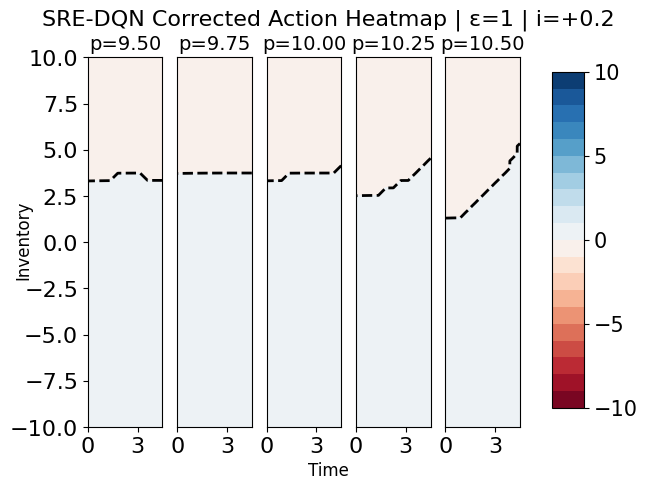

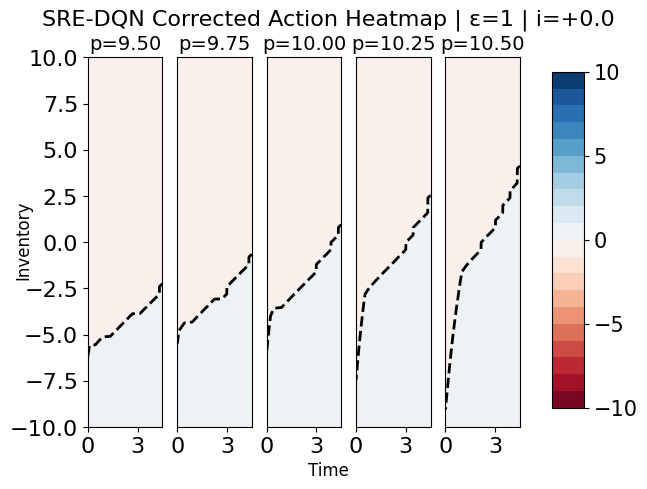

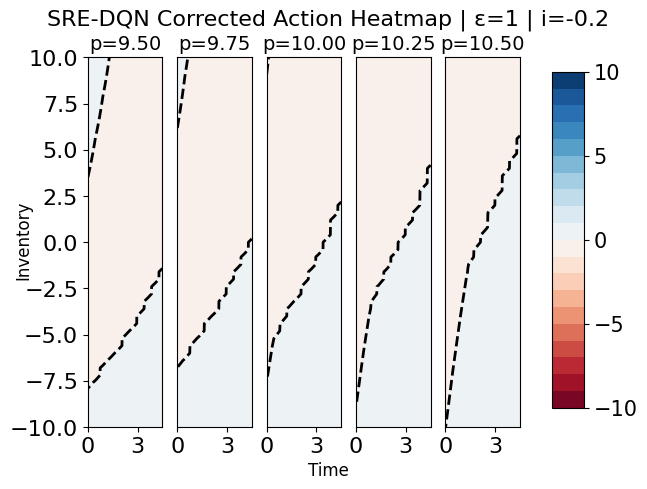

In [9]:

print('=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_corrected_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            mesh_fn=to_State_mesh_sre,
            mesh_kwargs={'eps': eps},
            figure_title=f'SRE-DQN Corrected Action Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )


## Evaluation Rollouts

The post-training evaluation uses these ten scenarios with fixed seeds and no epsilon decay:

| # | Scenario | Agent 0 | Agents 1-4 |
|---|----------|---------|------------|
| 1 | All Nash | Nash | Nash |
| 2 | All SRE (eps=0.01) | SRE eps=0.01 | SRE eps=0.01 |
| 3 | All SRE (eps=0.1) | SRE eps=0.1 | SRE eps=0.1 |
| 4 | All SRE (eps=0.5) | SRE eps=0.5 | SRE eps=0.5 |
| 5 | Nash vs SRE (eps=0.01) | Nash | SRE eps=0.01 |
| 6 | Nash vs SRE (eps=0.1) | Nash | SRE eps=0.1 |
| 7 | Nash vs SRE (eps=0.5) | Nash | SRE eps=0.5 |
| 8 | SRE (eps=0.01) vs Nash | SRE eps=0.01 | Nash |
| 9 | SRE (eps=0.1) vs Nash | SRE eps=0.1 | Nash |
| 10 | SRE (eps=0.5) vs Nash | SRE eps=0.5 | Nash |


In [10]:
NUM_TRIALS = 50
IT_LIM = 500  # episodes per trial
EVAL_BATCH_SIZE = 2000
EVAL_SRE_EPS_LIST = [0.01, 0.1, 0.5]
from tqdm.auto import tqdm

nash_spec = make_policy_spec(nash_agent, mode='nash')
sre_specs = {
    eps: make_policy_spec(sre_agents[eps], mode='sre', eps=eps)
    for eps in EVAL_SRE_EPS_LIST
}

scenario_specs = [('All Nash', [nash_spec for _ in range(num_players)])]
scenario_specs.extend(
    (f'All SRE (eps={eps:g})', [sre_specs[eps] for _ in range(num_players)])
    for eps in EVAL_SRE_EPS_LIST
)
scenario_specs.extend(
    (
        f'Nash vs SRE (eps={eps:g}; agent 0 Nash)',
        [nash_spec] + [sre_specs[eps] for _ in range(num_players - 1)],
    )
    for eps in EVAL_SRE_EPS_LIST
)
scenario_specs.extend(
    (
        f'SRE (eps={eps:g}) vs Nash (agent 0 SRE)',
        [sre_specs[eps]] + [nash_spec for _ in range(num_players - 1)],
    )
    for eps in EVAL_SRE_EPS_LIST
)
scenario_order = [name for name, _ in scenario_specs]

scenario_rewards = {}
for scenario_name, policy_specs in tqdm(scenario_specs, desc='Evaluation scenarios', unit='scenario'):
    scenario_rewards[scenario_name] = collect_mixed_rewards(
        sim_obj,
        norm_mean,
        norm_std,
        policy_specs,
        NUM_TRIALS,
        IT_LIM,
        seed=EVAL_SEED,
        desc=f'Collecting {scenario_name} rollouts...',
        eval_batch_size=EVAL_BATCH_SIZE,
    )

all_nash_rewards = scenario_rewards['All Nash']
all_sre_rewards = {
    eps: scenario_rewards[f'All SRE (eps={eps:g})']
    for eps in EVAL_SRE_EPS_LIST
}
nash_vs_sre_rewards = {
    eps: scenario_rewards[f'Nash vs SRE (eps={eps:g}; agent 0 Nash)']
    for eps in EVAL_SRE_EPS_LIST
}
sre_vs_nash_rewards = {
    eps: scenario_rewards[f'SRE (eps={eps:g}) vs Nash (agent 0 SRE)']
    for eps in EVAL_SRE_EPS_LIST
}

print('Done.')


Evaluation scenarios:   0%|          | 0/10 [00:00<?, ?scenario/s]

Done.


## Reward Distribution Box Plot


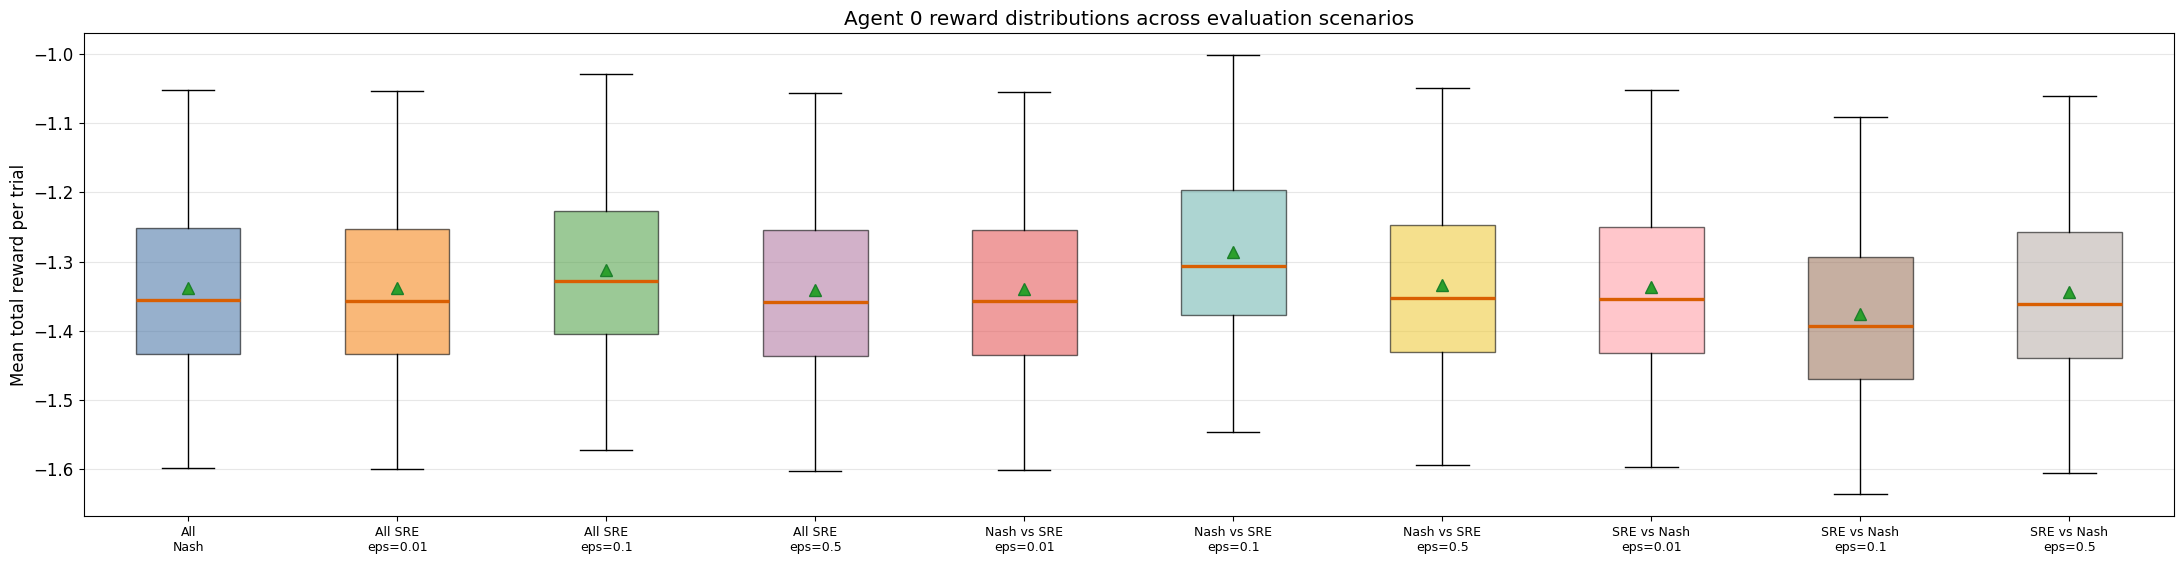

Saved reward box plot to: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/evaluation/seed_20260409/reward_boxplot_10_scenarios.png


In [11]:
def agent0_mean_total_reward(rewards):
    """Mean total reward for agent 0, averaged over episodes, per trial.
    rewards shape: [num_trials, it_lim, n_steps, n_agents]
    """
    return rewards.sum(dim=2)[..., 0].mean(dim=1).cpu().numpy()


scenario_agent0_rewards = {
    name: agent0_mean_total_reward(scenario_rewards[name])
    for name in scenario_order
}

scenario_plot_labels = {
    'All Nash': 'All\nNash',
    'All SRE (eps=0.01)': 'All SRE\neps=0.01',
    'All SRE (eps=0.1)': 'All SRE\neps=0.1',
    'All SRE (eps=0.5)': 'All SRE\neps=0.5',
    'Nash vs SRE (eps=0.01; agent 0 Nash)': 'Nash vs SRE\neps=0.01',
    'Nash vs SRE (eps=0.1; agent 0 Nash)': 'Nash vs SRE\neps=0.1',
    'Nash vs SRE (eps=0.5; agent 0 Nash)': 'Nash vs SRE\neps=0.5',
    'SRE (eps=0.01) vs Nash (agent 0 SRE)': 'SRE vs Nash\neps=0.01',
    'SRE (eps=0.1) vs Nash (agent 0 SRE)': 'SRE vs Nash\neps=0.1',
    'SRE (eps=0.5) vs Nash (agent 0 SRE)': 'SRE vs Nash\neps=0.5',
}
scenario_colors = {
    'All Nash': '#4C78A8',
    'All SRE (eps=0.01)': '#F58518',
    'All SRE (eps=0.1)': '#54A24B',
    'All SRE (eps=0.5)': '#B279A2',
    'Nash vs SRE (eps=0.01; agent 0 Nash)': '#E45756',
    'Nash vs SRE (eps=0.1; agent 0 Nash)': '#72B7B2',
    'Nash vs SRE (eps=0.5; agent 0 Nash)': '#EECA3B',
    'SRE (eps=0.01) vs Nash (agent 0 SRE)': '#FF9DA6',
    'SRE (eps=0.1) vs Nash (agent 0 SRE)': '#9D755D',
    'SRE (eps=0.5) vs Nash (agent 0 SRE)': '#BAB0AC',
}


def plot_reward_boxplots(file_name='reward_boxplot_10_scenarios.png'):
    names = scenario_order
    arrays = [scenario_agent0_rewards[name] for name in names]
    labels = [scenario_plot_labels[name] for name in names]
    fig, ax = plt.subplots(figsize=(22, 5.8))
    box = ax.boxplot(
        arrays,
        tick_labels=labels,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        meanprops=dict(
            marker='^',
            markerfacecolor='#2CA02C',
            markeredgecolor='#1B7F2A',
            markersize=8,
        ),
        medianprops=dict(color='#D95F02', linewidth=2.4),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )
    for patch, name in zip(box['boxes'], names):
        patch.set_facecolor(scenario_colors[name])
        patch.set_alpha(0.58)
    ax.set_title('Agent 0 reward distributions across evaluation scenarios')
    ax.set_ylabel('Mean total reward per trial')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(EVAL_DIR, file_name)
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved reward box plot to:', out_path)


os.makedirs(EVAL_DIR, exist_ok=True)
plot_reward_boxplots()


## Statistical Comparison

In [12]:
def describe(arr, name):
    return {
        'scenario': name,
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'median': float(np.median(arr)),
        'min': float(arr.min()),
        'max': float(arr.max()),
    }


rows = [
    describe(scenario_agent0_rewards[name], name)
    for name in scenario_order
]

print(f"{'Scenario':<48} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
print('-' * 96)
for row in rows:
    print(
        f"{row['scenario']:<48} {row['mean']:8.4f} {row['std']:8.4f} "
        f"{row['median']:8.4f} {row['min']:8.4f} {row['max']:8.4f}"
    )


Scenario                                             Mean      Std   Median      Min      Max
------------------------------------------------------------------------------------------------
All Nash                                          -1.3376   0.1279  -1.3553  -1.5982  -1.0523
All SRE (eps=0.01)                                -1.3384   0.1280  -1.3563  -1.5995  -1.0533
All SRE (eps=0.1)                                 -1.3122   0.1260  -1.3280  -1.5717  -1.0286
All SRE (eps=0.5)                                 -1.3411   0.1279  -1.3585  -1.6020  -1.0569
Nash vs SRE (eps=0.01; agent 0 Nash)              -1.3397   0.1280  -1.3574  -1.6008  -1.0544
Nash vs SRE (eps=0.1; agent 0 Nash)               -1.2863   0.1259  -1.3056  -1.5461  -1.0017
Nash vs SRE (eps=0.5; agent 0 Nash)               -1.3343   0.1279  -1.3521  -1.5940  -1.0493
SRE (eps=0.01) vs Nash (agent 0 SRE)              -1.3363   0.1279  -1.3541  -1.5969  -1.0512
SRE (eps=0.1) vs Nash (agent 0 SRE)               -1.3757

## Agent 0 Rank Distribution


Agent 0 rank counts within each head-to-head scenario
Scenario                                            1st    2nd    3rd    4th    5th
------------------------------------------------------------------------------------
Nash vs SRE (eps=0.01; agent 0 Nash)                  7      7      8     17     11
Nash vs SRE (eps=0.1; agent 0 Nash)                  13     10      9     14      4
Nash vs SRE (eps=0.5; agent 0 Nash)                   7     12      3     20      8
SRE (eps=0.01) vs Nash (agent 0 SRE)                  7      8      7     18     10
SRE (eps=0.1) vs Nash (agent 0 SRE)                   5      6      5     13     21
SRE (eps=0.5) vs Nash (agent 0 SRE)                   7      6      9     15     13


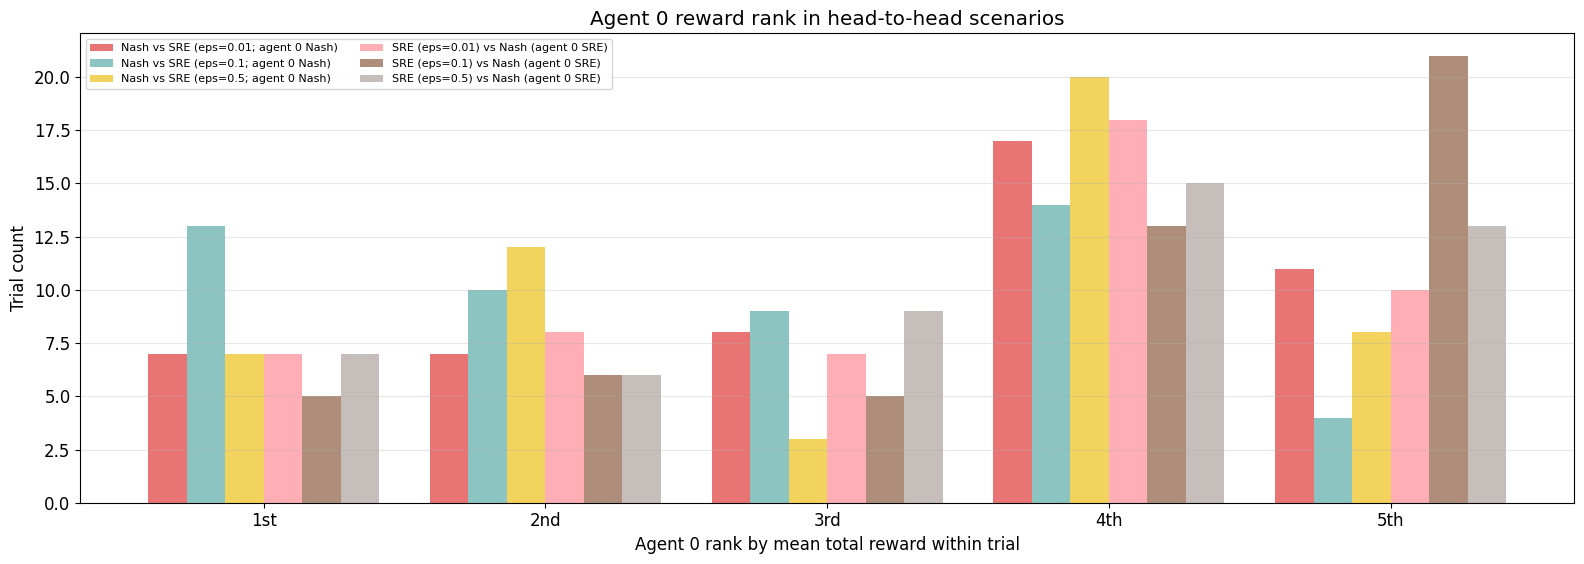

Saved rank distribution plot to: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/evaluation/seed_20260409/agent0_rank_distribution_head_to_head.png


In [13]:
HEAD_TO_HEAD_SCENARIOS = [
    name for name in scenario_order
    if name.startswith('Nash vs SRE') or name.startswith('SRE (eps=')
]


def per_trial_agent_rewards(rewards):
    """Mean total reward per agent for each evaluation trial.
    rewards shape: [num_trials, it_lim, n_steps, n_agents]
    returns: [num_trials, n_agents]
    """
    return rewards.sum(dim=2).mean(dim=1).detach().cpu().numpy()


def agent0_rank_counts(rewards):
    agent_rewards = per_trial_agent_rewards(rewards)
    agent0 = agent_rewards[:, [0]]
    ranks = 1 + np.sum(agent_rewards > agent0, axis=1)
    counts = np.array([(ranks == rank).sum() for rank in range(1, num_players + 1)])
    return counts, ranks, agent_rewards


rank_labels = [f'{rank}' for rank in range(1, num_players + 1)]
rank_counts = {}
rank_percentages = {}
for scenario_name in HEAD_TO_HEAD_SCENARIOS:
    counts, ranks, agent_rewards = agent0_rank_counts(scenario_rewards[scenario_name])
    rank_counts[scenario_name] = counts
    rank_percentages[scenario_name] = counts / counts.sum() * 100.0

print('Agent 0 rank counts within each head-to-head scenario')
print(f"{'Scenario':<48} {'1st':>6} {'2nd':>6} {'3rd':>6} {'4th':>6} {'5th':>6}")
print('-' * 84)
for scenario_name in HEAD_TO_HEAD_SCENARIOS:
    counts = rank_counts[scenario_name]
    print(
        f"{scenario_name:<48} "
        f"{counts[0]:6d} {counts[1]:6d} {counts[2]:6d} {counts[3]:6d} {counts[4]:6d}"
    )

x = np.arange(num_players)
width = min(0.82 / max(len(HEAD_TO_HEAD_SCENARIOS), 1), 0.16)
fig, ax = plt.subplots(figsize=(16, 5.8))
for idx, scenario_name in enumerate(HEAD_TO_HEAD_SCENARIOS):
    offset = (idx - (len(HEAD_TO_HEAD_SCENARIOS) - 1) / 2) * width
    ax.bar(
        x + offset,
        rank_counts[scenario_name],
        width=width,
        label=scenario_name,
        color=scenario_colors.get(scenario_name),
        alpha=0.82,
    )

ax.set_xticks(x)
ax.set_xticklabels(['1st', '2nd', '3rd', '4th', '5th'])
ax.set_xlabel('Agent 0 rank by mean total reward within trial')
ax.set_ylabel('Trial count')
ax.set_title('Agent 0 reward rank in head-to-head scenarios')
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
rank_plot_path = os.path.join(EVAL_DIR, 'agent0_rank_distribution_head_to_head.png')
fig.savefig(rank_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved rank distribution plot to:', rank_plot_path)


## Save Results

In [14]:
comparison_dict = {
    'nash_loss': nash_loss,
    'sre_losses': sre_losses,
    'scenario_order': scenario_order,
    'scenario_rewards': scenario_rewards,
    'scenario_agent0_rewards': scenario_agent0_rewards,
    'config': {
        'BASE_SEED': BASE_SEED,
        'EVAL_SEED': EVAL_SEED,
        'MAX_STEPS': MAX_STEPS,
        'NUM_TRIALS': NUM_TRIALS,
        'IT_LIM': IT_LIM,
        'EVAL_BATCH_SIZE': EVAL_BATCH_SIZE,
        'EVAL_SRE_EPS_LIST': EVAL_SRE_EPS_LIST,
        'SRE_EPS_LIST': SRE_EPS_LIST,
        'SRE_EPS_REG': SRE_EPS_REG,
        'nash_best_checkpoint_path': nash_best_checkpoint_path,
        'sre_best_checkpoint_paths': sre_best_checkpoint_paths,
        'loaded_from_seed_pt_files': True,
        'nash_model_dir': NASH_MODEL_DIR,
        'sre_model_dirs': SRE_MODEL_DIRS,
        'evaluation_dir': EVAL_DIR,
    },
}

out_path = os.path.join(EVAL_DIR, 'sre_vs_nash_comparison.pickle')
with open(out_path, 'wb') as f:
    pickle.dump(comparison_dict, f)
print('Saved comparison results to:', out_path)


Saved comparison results to: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/evaluation/seed_20260409/sre_vs_nash_comparison.pickle
